# QM9: exploration and target selection

**Phase 1.** Two questions to answer before any modelling:

1. What is actually in this dataset?
2. Which property should we predict — and can we justify the choice with evidence rather than taste?

The second question matters more than it looks. QM9 ships 15 properties, and some of them
can be predicted almost perfectly by a model that understands no chemistry whatsoever.
Picking one of those would produce a spectacular-looking result that means nothing.

In [1]:
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from molecular_property_predictor.data import PROPERTY_NAMES, load_qm9, split_dataset

# Notebooks run from notebooks/, the data paths are relative to the repo root.
ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

df = load_qm9(raw_dir=ROOT / "data/raw", processed_dir=ROOT / "data/processed")
print(f"{len(df):,} molecules x {df.shape[1]} columns")

130,831 molecules x 25 columns


## What we loaded

133,885 molecules were published; 3,054 were flagged by the original authors as failing a
consistency check (the relaxed geometry and the original geometry parse to different SMILES),
and we exclude them. 133,885 − 3,054 = **130,831**.

Energetic properties have been converted from Hartree to **eV** on load, so our errors are
directly comparable to the published literature.

In [2]:
df[["index", "n_atoms", "smiles_gdb17", "mu", "alpha", "homo", "lumo", "gap", "U0", "Cv"]].head()

,index,n_atoms,smiles_gdb17,mu,alpha,homo,lumo,gap,U0,Cv
0,1,5,C,0.0000,13.21,-10.549854,3.186453,13.736308,-1101.487799,6.469
1,2,4,N,1.6256,9.46,-6.993326,2.255824,9.249150,-1538.147744,6.316
2,3,3,O,1.8511,6.31,-7.967494,1.869422,9.836916,-2079.077857,6.002
3,4,4,C#C,0.0000,16.28,-7.741639,1.376896,9.118536,-2103.669467,8.574
4,5,3,C#N,2.8937,12.99,-9.806984,0.519737,10.329442,-2541.866964,6.278


## Size and composition

The single most important structural fact about QM9 — and the one that shapes everything
below — is how *little* the molecules vary in size.

In [3]:
df["n_heavy"] = df["elements"].apply(lambda els: sum(e != "H" for e in els))

print(f"total atoms  : min {df.n_atoms.min():2d}  max {df.n_atoms.max():2d}  mean {df.n_atoms.mean():.2f}")
print(f"heavy atoms  : min {df.n_heavy.min():2d}  max {df.n_heavy.max():2d}  mean {df.n_heavy.mean():.2f}")
print()
print(f"{(df.n_heavy == 9).mean():.1%} of molecules have the maximum 9 heavy atoms")
print()

counts = Counter()
for els in df["elements"]:
    counts.update(els)
total = sum(counts.values())
print("element composition")
for element, n in counts.most_common():
    print(f"  {element}: {n:>9,}  ({100 * n / total:5.2f}%)")

total atoms  : min  3  max 29  mean 18.03


heavy atoms  : min  1  max  9  mean 8.80

83.3% of molecules have the maximum 9 heavy atoms

element composition
  H: 1,208,486  (51.22%)
  C:   831,925  (35.26%)
  O:   183,265  ( 7.77%)
  N:   132,498  ( 5.62%)
  F:     3,036  ( 0.13%)


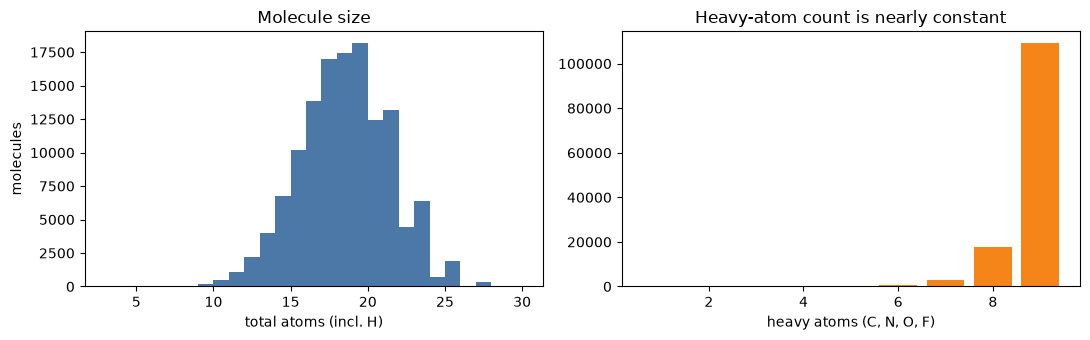

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))

axes[0].hist(df["n_atoms"], bins=range(df.n_atoms.min(), df.n_atoms.max() + 2), color="#4C78A8")
axes[0].set_xlabel("total atoms (incl. H)")
axes[0].set_ylabel("molecules")
axes[0].set_title("Molecule size")

axes[1].hist(df["n_heavy"], bins=range(1, 11), color="#F58518", align="left", rwidth=0.8)
axes[1].set_xlabel("heavy atoms (C, N, O, F)")
axes[1].set_title("Heavy-atom count is nearly constant")

plt.tight_layout()
plt.show()

## Choosing the target: the trap

Some properties are **extensive** — they scale with how much molecule there is. Total internal
energy `U0` is the obvious case: a molecule with more carbon atoms simply has more energy in it.

A model predicting an extensive property can score brilliantly by learning nothing but
*"count the atoms and multiply"*. That is not chemistry, and a headline R² built on it is
misleading.

The clean way to test this is to fit the dumbest possible chemistry-free model — ordinary
least squares on **atom counts only** (how many H, C, N, O, F, plus an intercept). It knows
nothing about bonds, geometry, or structure. Whatever R² it reaches is the score a target
gives away for free.

In [5]:
elements = ["H", "C", "N", "O", "F"]
X = np.array([[Counter(els)[e] for e in elements] for els in df["elements"]], dtype=float)
X = np.column_stack([X, np.ones(len(X))])  # + intercept

results = []
for name in PROPERTY_NAMES:
    y = df[name].to_numpy()
    beta, *_ = np.linalg.lstsq(X, y, rcond=None)
    prediction = X @ beta
    r2 = 1 - ((y - prediction) ** 2).sum() / ((y - y.mean()) ** 2).sum()
    results.append(
        {
            "property": name,
            "r2_atom_counts": r2,
            "mae_atom_counts": np.abs(y - prediction).mean(),
            "mae_predict_mean": np.abs(y - y.mean()).mean(),
        }
    )

atom_count_model = pd.DataFrame(results).sort_values("r2_atom_counts", ascending=False)
atom_count_model.style.format({
    "r2_atom_counts": "{:.4f}",
    "mae_atom_counts": "{:.4f}",
    "mae_predict_mean": "{:.4f}",
}).background_gradient(subset=["r2_atom_counts"], cmap="RdYlGn_r")

,property,r2_atom_counts,mae_atom_counts,mae_predict_mean
11,U,1.0000,0.8645,841.5287
12,H,1.0000,0.8645,841.5287
10,U0,1.0000,0.8656,841.5322
13,G,1.0000,0.8696,841.5414
9,zpve,0.9971,0.0384,0.7172
4,alpha,0.8611,2.1652,6.2918
14,Cv,0.7035,1.7337,3.2076
6,lumo,0.4555,0.7661,1.0510
7,gap,0.4016,0.8203,1.0742
8,r2,0.3011,165.1640,202.5764


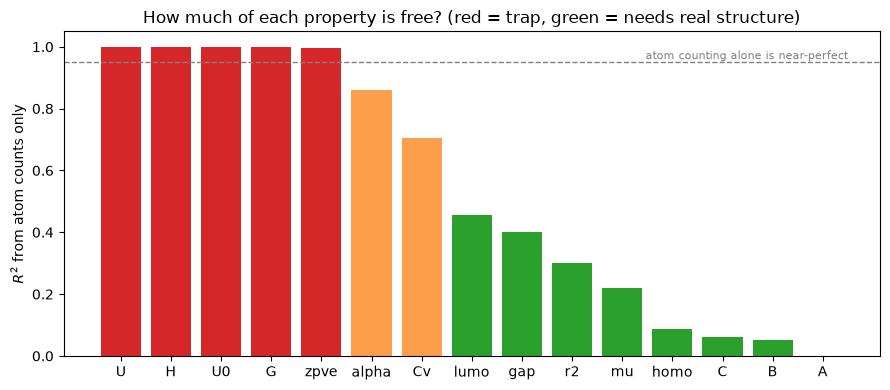

In [6]:
fig, ax = plt.subplots(figsize=(9, 4))
colors = ["#D62728" if r > 0.95 else "#FF9E4A" if r > 0.5 else "#2CA02C" for r in atom_count_model["r2_atom_counts"]]
ax.bar(atom_count_model["property"], atom_count_model["r2_atom_counts"], color=colors)
ax.axhline(0.95, ls="--", c="grey", lw=1)
ax.text(len(atom_count_model) - 0.5, 0.96, "atom counting alone is near-perfect", ha="right", fontsize=8, color="grey")
ax.set_ylabel("$R^2$ from atom counts only")
ax.set_title("How much of each property is free? (red = trap, green = needs real structure)")
plt.tight_layout()
plt.show()

### Reading the result

`U0`, `U`, `H` and `G` come out at **R² = 1.0000**. Not 0.99 — the thermodynamic energies are,
to four decimal places, a linear function of how many of each element the molecule contains.
`zpve` is barely better at 0.9971. Predicting any of these would produce an impressive number
and demonstrate nothing.

One nuance worth recording, because it corrects the obvious intuition: the usual way to describe
this is "extensive properties scale with molecule *size*". In QM9 that framing fails —
correlating `U0` against heavy-atom count gives only r ≈ −0.57, because **almost every molecule
has 9 heavy atoms**, so size barely varies and cannot explain anything. The leak is not size,
it is *composition*. Only when you regress on the per-element counts does the R² = 1.0000
become visible.

The orbital energies behave completely differently:

| property | R² from atom counts | interpretation |
|---|---|---|
| `homo` | 0.086 | almost entirely structural |
| `gap`  | 0.402 | substantially structural |
| `lumo` | 0.456 | substantially structural |

All three are legitimate targets. We take **`lumo`** — it is what the README already promises,
it is intensive, and atom counting leaves more than half its variance unexplained, so there is
real structural signal for a model to earn.

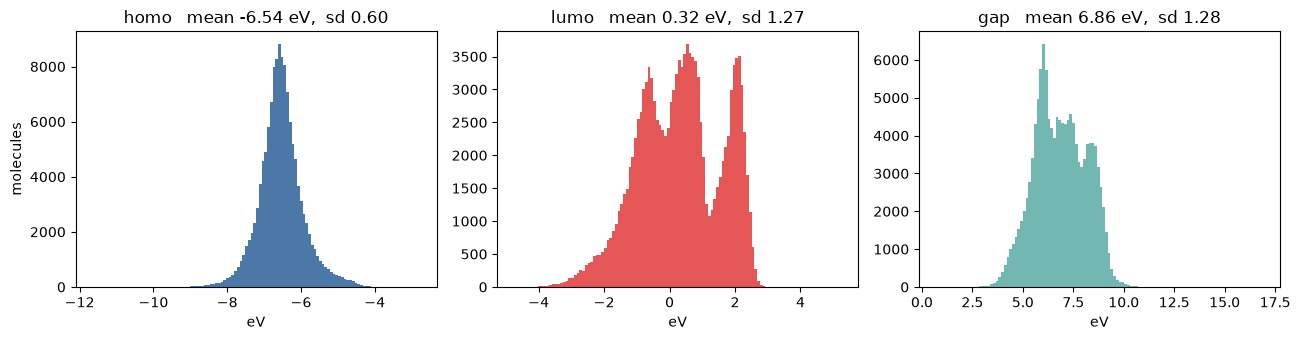

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))
for ax, name, color in zip(axes, ["homo", "lumo", "gap"], ["#4C78A8", "#E45756", "#72B7B2"]):
    ax.hist(df[name], bins=120, color=color)
    ax.set_title(f"{name}   mean {df[name].mean():.2f} eV,  sd {df[name].std():.2f}")
    ax.set_xlabel("eV")
axes[0].set_ylabel("molecules")
plt.tight_layout()
plt.show()

## The number to beat

Before building anything, write down what "doing nothing" scores. If you always predict the
training mean, your mean absolute error on `lumo` is:

In [8]:
for name in ["homo", "lumo", "gap"]:
    baseline = np.abs(df[name] - df[name].mean()).mean()
    print(f"{name:<5}  always-predict-the-mean MAE = {baseline:.4f} eV")

homo   always-predict-the-mean MAE = 0.4398 eV
lumo   always-predict-the-mean MAE = 1.0510 eV
gap    always-predict-the-mean MAE = 1.0742 eV


Any model that cannot beat **1.05 eV** on `lumo` has contributed nothing.

For scale at the other end: published graph neural networks on this target reach roughly
0.02–0.04 eV, using considerably heavier machinery than we intend to build. We are not chasing
that number, and this project would be dishonest if it implied otherwise — it is a yardstick for
interpreting whatever we get, not a goal.

## The split

Three sets, not two:

- **train** — the model fits its parameters here
- **validation** — we make *our* choices here (architecture, learning rate, when to stop)
- **test** — touched once, at the very end

The reason for the third set is subtle and worth stating plainly: the moment you pick anything
by looking at a set, that set stops being an unbiased estimate of unseen performance. Choosing
the best of twenty configurations by validation score means the winning score is partly luck,
and luck does not generalise. The test set is the only honest number, and it stays honest only
for as long as it stays untouched.

The split is seeded, so the partition is identical in Phase 3 and Phase 4 and the two results
remain comparable.

In [9]:
train, validation, test = split_dataset(df, train_frac=0.8, val_frac=0.1, seed=0)

for name, part in [("train", train), ("validation", validation), ("test", test)]:
    print(f"{name:<11} {len(part):>7,}  ({len(part) / len(df):.1%})   mean lumo {part['lumo'].mean():.4f} eV")

assert not set(train["index"]) & set(validation["index"])
assert not set(train["index"]) & set(test["index"])
assert not set(validation["index"]) & set(test["index"])
assert len(train) + len(validation) + len(test) == len(df)
print("\nsplits are disjoint and cover every molecule")

train       104,664  (80.0%)   mean lumo 0.3250 eV
validation   13,083  (10.0%)   mean lumo 0.3213 eV
test         13,084  (10.0%)   mean lumo 0.2992 eV



splits are disjoint and cover every molecule


The three means agree to within about 0.03 eV. That is the right order of magnitude for sampling
noise here: `lumo` has a standard deviation of 1.27 eV, so the standard error of the mean for a
13,000-molecule set is 1.27/√13084 ≈ 0.011 eV. A *large* gap between the three would have
signalled that the split picked up structure instead of shuffling it away.

### One honest caveat

A *random* split is the QM9 convention, and it is optimistic. QM9 enumerates molecules
exhaustively, so near-identical structures land on both sides of the split — the test score
measures interpolation *within* a chemical space, not generalisation to genuinely new chemistry.
A scaffold split (grouping by molecular skeleton) would be stricter and would score worse.
We use the random split for comparability with published work, and record the limitation here
rather than quietly banking the easier number.

## Conclusions carried into Phase 2

- **130,831** molecules after excluding the 3,054 flagged as uncharacterized
- Target: **`lumo`**, in eV — intensive, and atom counting explains only 46% of it
- Beat-me baseline: **1.05 eV** MAE from predicting the mean
- Split: 80 / 10 / 10, seeded, reproducible
- Avoid `U0`, `U`, `H`, `G`, `zpve` as targets — atom counting alone gives R² ≈ 1.0
- 3D coordinates are parsed and cached, so geometry-based representations stay available